# How often do laboratories say functional evidence exists — and how often do they say it doesn't?

**Version 6.** The first version answered this with a ratio of 5.9 denials per
claim. That number was wrong, and the way it was wrong is worth stating before
anything else, because it shapes everything below.

The denial pattern contained `(has|have) not been (functionally )?(characterized|studied|reported)`.
The `functionally` was optional. So the pattern fired on *"this variant has not
been reported in the literature in individuals affected with…"* — a statement
about **case reports**, which is PS4 territory, not about functional evidence at
all. That single alternative produced 87.7% of all denial matches, and the word
"functionally" appeared in none of them.

An audit caught it by hand-reading 130 submissions. In the denial-only stratum,
**0 of 30** were genuine denials of functional evidence. The claim stratum was
56.7% correct, and most of its errors were denials phrased in ways the pattern
never anticipated: *"predictions yet to be confirmed by functional studies"*,
*"no published functional evidence has been identified"*, *"in the absence of
RNA/functional studies"*.

## What changed, and why the shape of this notebook is different

The first version tested its patterns against six probes, all of which described
functional evidence. None described case reports. It tested the failure mode I
had imagined and not the one I hadn't, then reported a ratio as if it were a
measurement.

This version does three things differently:

- **Accuracy is measured, not assumed.** The 130 hand-read submissions are a
  labelled validation set. Precision and recall against it are computed in
  section 5 and printed with every headline figure. If the classifier is 60%
  accurate, the output says so.
- **The unit of analysis is the laboratory.** The panel-wide ratio was a
  Simpson's paradox: one submitter accounted for 79.6% of matches, and removing
  it inverted the direction. Within-laboratory rates are the honest unit, and
  they are what section 6 reports.
- **The bare ACMG codes are read.** 155 submissions assert functional evidence
  by writing `PS3` and nothing else. No prose pattern reaches them.

## What is still not measured

Whether any claim is true. That needs the cited papers read, and the feasibility
check found only 26% have open full text. This notebook measures what
laboratories *wrote*, with a stated error rate — which is a smaller claim than
version 1 made, and one the data supports.

## 1. Setup

In [1]:
import csv, glob, gzip, json, os, re, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

pd.set_option("display.width", 200)
OUT = Path("panel_claims_v2"); OUT.mkdir(parents=True, exist_ok=True)
FIG = OUT / "figures"; FIG.mkdir(exist_ok=True)

SUBMISSION_URL = ("https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/"
                  "submission_summary.txt.gz")

PANEL = ["BRAF", "HRAS", "KRAS", "LZTR1", "MAP2K1", "MAP2K2", "NRAS",
         "PTPN11", "RAF1", "RIT1", "SHOC2", "SOS1", "SOS2"]

# Genes with a score set in MaveDB, from the frozen MAVE snapshot. Context for
# reading the figures, not a verdict on any claim: MaveDB holds multiplexed
# assays only, and a single-variant experiment in a paper never appears there.
HAS_MAVE = {"BRAF", "HRAS", "KRAS", "RAF1"}

WANTED = ["VariationID", "ClinicalSignificance", "Description",
          "ExplanationOfInterpretation", "SubmittedGeneSymbol", "Submitter",
          "SCV", "DateLastEvaluated", "ReviewStatus", "CollectionMethod"]

def locate(filename):
    """Find a file anywhere under the Kaggle input or working tree.

    The labelled samples arrive as attached datasets, and the path depends on
    what the dataset was named. Hard-coding it means validation silently does
    not run - which is how a notebook ends up printing unvalidated numbers, the
    exact failure this version exists to fix.
    """
    for pattern in (f"/kaggle/input/**/{filename}",
                    f"/kaggle/working/**/{filename}",
                    f"./**/{filename}"):
        hits = [Path(p) for p in glob.glob(pattern, recursive=True)]
        hits = [p for p in hits if p.is_file()]
        if hits:
            return max(hits, key=lambda p: p.stat().st_mtime)
    return None


# Three labelled sets, and which is which changed with each version. A set stops
# being held out the moment a pattern is written from one of its rows, and
# calling it held out afterwards is how a fit gets reported as an accuracy.
#
#   130 rows - generated the v2 patterns.                    TRAINING
#   110 rows - held out for v2. Then CONDITIONAL, the vendor
#              carve-out and two DENIAL branches were each
#              written from a specific row in it.            TRAINING (for v3)
#    90 rows - drawn after v3 was frozen, disjoint from both. EVALUATION
AUDIT_SAMPLE = locate("panel_claims_audit_sample130_rev.csv")
TRAIN2_SAMPLE = locate("panel_claims_v2_heldout_110_rev.csv")
HELDOUT_SAMPLE = locate("panel_claims_v3_heldout_90_rev.csv")

for label, p in (("training  (130 rows)", AUDIT_SAMPLE),
                 ("training2 (110 rows)", TRAIN2_SAMPLE),
                 ("held out  ( 90 rows)", HELDOUT_SAMPLE)):
    print(f"{label:22s} {p if p else 'NOT FOUND'}")
if HELDOUT_SAMPLE is None:
    print("\nWithout the held-out set there is no honest accuracy figure.")
    print("Attach both CSVs: Add Input -> Upload -> New Dataset.")

training  (130 rows)   /kaggle/input/datasets/fernandosr85/clinvar-claim-audit-labels/panel_claims_audit_sample130_rev.csv
training2 (110 rows)   /kaggle/input/datasets/fernandosr85/clinvar-claim-audit-labels/panel_claims_v2_heldout_110_rev.csv
held out  ( 90 rows)   /kaggle/input/datasets/fernandosr85/clinvar-claim-audit-labels/panel_claims_v3_heldout_90_rev.csv


## 2. What counts as a claim, and what counts as a denial


Every pattern below was derived from submissions that a human read and labelled.
That is the opposite of version 1, where the patterns came first and the reading
came after — and where the reading found them wrong.

**A claim asserts that an experiment was performed.** Not that a variant is
predicted damaging, not that a vendor model expects disruption, not that the
residue is conserved. The distinction is the whole point: an experiment is
PS3/BS3 and can reach Strong, a prediction is PP3/BP4 and stops at Supporting.

**A denial asserts that no such experiment exists.** The critical fix is that a
denial must reference function explicitly. Absence from the *literature* is a
different statement, about case reports, and it is what wrecked version 1.

In [2]:
# --------------------------------------------------------------------------
# CLAIM: an experiment is asserted to have been done.
# Phrases taken from submissions labelled TRUE_CLAIM by hand.
# --------------------------------------------------------------------------
# The verb list is what makes this work, and it came from reading the missed
# claims rather than from imagination: suggest, found, provide and evaluating
# were all absent from the first draft and all appear in genuine claims.
# Every entry is a stem except one: "shown" was the past participle only, so
# "functional studies SHOWED that..." matched nothing - 41 unlabelled rows
# across six submitters. "show" is the stem and covers show/shows/showed/shown.
_ASSERT_VERB = (r"(have |has |were |was )?(show|demonstrat|indicat|reveal|"
                r"suggest|support|confirm|found|provide|establish|evaluat|"
                r"identif|report)")

CLAIM = re.compile(
    r"experimental (stud(y|ies)|evidence|analys[ei]s)[^.;]{0,45}?"
    + _ASSERT_VERB + r"|"
    r"(published |prior |in.?vitro |in.?vivo )*functional "
    r"(stud(y|ies)|assay|analys[ei]s|experiment|data|evidence|"
    # up to a short phrase may sit between the noun and its verb - "functional
    # analyses OF THE VARIANT PROTEIN found" - but never across a sentence end.
    r"characteri[sz]ation)[^.;]{0,45}?" + _ASSERT_VERB + r"|"
    r"in.?(vitro|vivo) (experimental |functional )?"
    r"(stud|assay|analys|data|experiment)|"
    r"(RNA|splicing|cDNA|mRNA|minigene) (stud(y|ies)|analys[ei]s|assay)"
    r"[^.;]{0,45}?" + _ASSERT_VERB + r"|"
    r"(zebrafish|mouse|murine|yeast|xenopus|drosophila) (model|embryo|assay)|"
    r"(phosphatase|kinase|GTPase|ERK|MAPK) activity (was|were|is|assay)|"
    r"(reduced|increased|elevated|impaired|abolished) "
    r"(phosphatase|kinase|catalytic|GTPase|binding) activity",
    re.I)

# One vendor sentence has to be carved out by name. Invitae writes "Evidence
# Modeling incorporating data from in vitro experimental studies (internal
# data)" - that is their proprietary model, not an assay on this variant, and
# it accounted for every claim false positive in the first scored run. The
# notebook's own probe set already treats Evidence Modeling as not-a-claim;
# this makes the longer form agree.
VENDOR_MODEL = re.compile(
    r"[^.]*(Evidence Modeling|performed at [A-Z][a-z]+ incorporating data)"
    r"[^.]{0,300}\.", re.I)

# The bare ACMG code. 155 submissions assert functional evidence this way and
# nothing else - invisible to any prose pattern. Word-bounded so PS3 inside a
# longer token does not fire, and BS3 counted separately as its own assertion.
CODE_PS3 = re.compile(r"(?<![A-Za-z0-9_])(PS3|BS3)(_(very)?[Ss]trong|"
                      r"_[Mm]oderate|_[Ss]upporting)?(?![A-Za-z0-9_])")

# --------------------------------------------------------------------------
# DENIAL: no such experiment exists. Every alternative names function, RNA or
# an experiment. Absence from the literature is NOT here - that is the bug.
# --------------------------------------------------------------------------
DENIAL = re.compile(
    r"no (direct |published |reported |available )*(experimental|functional) "
    r"(evidence|stud|assay|data|analys)|"
    r"(has|have) not been (functionally|experimentally) "
    r"(characteri[sz]ed|studied|tested|assessed|evaluated|validated)|"
    # An adjective may sit between "by" and the noun: "confirmed by PUBLISHED
    # functional studies". This is the third branch broken by an intervening
    # word - v1 by "no published functional evidence", v2 by "is currently
    # unknown", this one by "by published functional studies", 93 rows. Section
    # 3 now tests for the class.
    r"yet to be (confirmed|validated|assessed) by "
    r"(published |prior |reported |conclusive |additional |further )*"
    r"(functional|experimental|RNA)|"
    r"(not|never) been (confirmed|validated|corroborated) by "
    r"(published |prior |reported |conclusive |additional |further )*"
    r"(functional|experimental|RNA)|"
    r"in the absence of (RNA[/ ]?)?(and[/ ]?)?functional (stud|assay|data|analys)|"
    r"(absence|lack|paucity) of (published |reported )?"
    r"(functional|experimental|RNA) (stud|evidence|data|assay|analys)|"
    r"functional (stud(y|ies)|data|evidence|assay) (are|is|were|was) "
    r"(not available|lacking|absent|unavailable|not reported)|"
    # "is CURRENTLY unknown" - an adverb sits between the verb and the state,
    # and "remains to be determined" is the same statement in another shape.
    r"(exact |precise )?functional (effect|impact|consequence|significance) "
    r"[^.;]{0,40}?(is|remains|are) (currently |presently |still |as yet )?"
    r"(unknown|unclear|uncertain|not established|undetermined|"
    r"to be (determined|established|elucidated))|"
    # The qualifier is REQUIRED, not optional. Written optional, this branch
    # matches "additional studies are required to fully establish its clinical
    # significance" - a statement about evidence in general, not about assays.
    # That is the same defect that made version 1 wrong, and writing it twice is
    # why section 3 now tests the class rather than the instance.
    r"(additional|further|more) (functional|experimental|RNA) stud(y|ies) "
    r"(are|is) (needed|required|warranted)|"
    r"(no|without) (functional|experimental) (characteri[sz]ation|validation)|"
    # "Experimental studies ... are not available" - the noun-first form, which
    # no other branch reaches.
    # Two shapes of the same statement: "studies ARE NOT available" and
    # "studies HAVE NOT BEEN performed". An earlier version accepted only the
    # first, and the second is 45 lines in this panel - the largest single
    # recall hole any audit found.
    r"(experimental|functional|RNA) (stud(y|ies)|assay|data|analys[ei]s)"
    r"[^.;]{0,40}?(are|is|were|was) not "
    r"(available|reported|performed|done|conducted|undertaken)|"
    r"(experimental|functional|RNA) (stud(y|ies)|assay|data|analys[ei]s)"
    r"[^.;]{0,40}?(have|has) not been "
    r"(available|reported|performed|done|conducted|undertaken|"
    r"identified|described)|"
    r"(yet to be|not yet been) (functionally|experimentally) "
    r"(assessed|evaluated|tested|characteri[sz]ed)|"
    r"nor (been )?evaluated[^.;]{0,30}(in vivo|in vitro|functional)",
    re.I)

# --------------------------------------------------------------------------
# PREDICTION: computational, and therefore neither of the above. Kept as its
# own axis because version 1's central surprise - that half of "claims" also
# cited a predictor - turned out to be half of them BEING predictions.
# --------------------------------------------------------------------------
PREDICTION = re.compile(
    r"in silico|computational (predict|tool|analys|model)|"
    r"(REVEL|CADD|PolyPhen|SIFT|AlphaMissense|MutationTaster|Provean|SpliceAI|"
    r"BayesDel|MetaSVM|GERP|PhyloP)|"
    r"Evidence Modeling|prediction (tool|algorithm|program)|"
    r"predicted (to be |as )?(damaging|deleterious|pathogenic|benign|tolerated)",
    re.I)

# An assertion in a conditional clause is not an assertion.
# An assertion inside a conditional clause is not an assertion: "until a
# functional study is identified" describes an assay that does not exist.
#
# The last branch of an earlier version read "(is|are) (needed|required)" with no
# further context, and killed sentences like "functional studies suggest mildly
# increased kinase activity; however, additional evidence is needed to confirm
# this finding". The assay exists there - the caveat is about confirming it. A
# reservation about an experiment is not the absence of one. Eight genuine claims
# were lost to those four words, so the branch now requires the subject.
CONDITIONAL = re.compile(
    r"^[^.;]{0,30}\b(until|unless|if|once|pending|awaiting)\b[^.;]{0,80}"
    r"(functional|experimental) (stud|assay|evidence|analys|data)|"
    r"(functional|experimental) (stud|assay|evidence)[^.;]{0,40}"
    r"\b(would|could|will|may) be\b",
    re.I)

# NOTE ON A FILTER THAT WAS REMOVED
#
# An earlier draft filtered out sentences naming "the wild-type residue" or
# "another substitution at this codon", on the theory that an assay on a
# different subject is PM5 rather than PS3. A third hand-read audit measured it:
# the filter suppressed 24 claims, 18 of them genuine. Three real assays lost per
# false one caught.
#
# The wild-type branch was exactly backwards. Every line it matched described an
# assay ON this variant, reported against its control - "altered phosphatase
# activity compared to wild-type protein". Naming the control is what a
# well-described experiment does; the filter read it as disqualifying. Two of the
# four branches matched nothing at all in 200 labelled rows.
#
# The underlying problem is real - an assay on a neighbouring variant is not PS3
# evidence for this one - but it is a reading problem, not a matching one, and it
# belongs in the limitations with its measured size rather than in a pattern that
# does more harm than good.


# Sentence boundaries. Crude on purpose: PMIDs, decimals and "et al." all
# contain periods, and a split that mangles them is worse than one that
# occasionally joins two sentences.
_SENT = re.compile(r"(?<=[.;])\s+(?=[A-Z(])")


# The literature sentence that produced version 1's error, kept as an explicit
# named pattern so it can be counted rather than silently absorbed.
LITERATURE_ABSENCE = re.compile(
    r"(has|have) not been (reported|described|observed|identified) in "
    r"(the )?(literature|individuals|patients|affected)",
    re.I)

## 3. Regression tests


These are not illustrative. They are the cases that version 1 got wrong, plus
the cases it got right, and the notebook refuses to continue if any of them
break. A pattern edit that fixes one thing and breaks another stops here rather
than at the end of a six-million-row scan.

In [3]:
# One submitter's export breaks words across a line boundary: "functional evid
# ence", "in vit ro". Three consecutive audits found this, so it is repaired at
# the input rather than by widening every pattern to tolerate a stray space.
_WORDWRAP = re.compile(
    r"\b(evid|stud|functi|experim|activ|analys|assa)\s+"
    r"(ence|ies|onal|ental|ity|is|ys|y)\b", re.I)


def _mend(t):
    return _WORDWRAP.sub(lambda m: m.group(1) + m.group(2), t)


def classify(text):
    """Return the four flags for one submission comment.

    Classification is per sentence, then aggregated. A comment routinely holds
    both an assertion and a denial - "functional studies show X; further studies
    are needed for Y" - and reading the whole comment as one block lets either
    one contaminate the other. Within a sentence, denial wins: "no published
    functional evidence has been identified" contains the words a claim uses,
    and the audit confirmed that giving denial precedence swallows no genuine
    claims (0 of 30 checked by hand).
    """
    t = _mend(str(text or ""))
    # Invitae's proprietary model cites in-vitro data without being an assay on
    # this variant. Removing the whole sentence stops it supplying a claim,
    # while any genuine claim elsewhere in the comment still counts.
    t = VENDOR_MODEL.sub(" ", t)

    claim = denial = False
    for s in _SENT.split(t):
        # A conditional is not an assertion. "until a functional study is
        # identified" and "if experimental evidence are reported" describe an
        # assay that does not exist yet; reading them as claims inverts them.
        if CONDITIONAL.search(s):
            continue
        if not s.strip():
            continue
        d = bool(DENIAL.search(s))
        c = (bool(CLAIM.search(s)) or bool(CODE_PS3.search(s))) and not d
        claim = claim or c
        denial = denial or d
    return {
        "claim": claim,
        "denial": denial,
        "prediction": bool(PREDICTION.search(t)),
        "lit_absence": bool(LITERATURE_ABSENCE.search(t)),
    }


# (text, expect_claim, expect_denial, why it is here)
TESTS = [
    # --- the failure that killed version 1 --------------------------------
    ("This variant has not been reported in the literature in individuals "
     "affected with BRAF-related conditions.", False, False,
     "literature absence is about case reports, not function - v1 read it as a denial"),
    ("This sequence change replaces glutamic acid with glutamine at codon 76. "
     "This variant has not been reported in the literature.", False, False,
     "the Invitae template that produced 87.7% of v1's denials"),

    # --- genuine claims, verbatim from TRUE_CLAIM rows --------------------
    ("Experimental studies have shown that this missense change affects PTPN11 "
     "function (PMID: 15834506).", True, False, "the canonical Invitae claim"),
    ("Published functional studies demonstrate a damaging effect on effector "
     "activation resulting in reduced stimulus-dependent signalling.", True, False,
     "GeneDx claim"),
    ("Published functional studies demonstrated that zebrafish embryos injected "
     "with RIT1 mRNA carrying p.(E81G) exhibit craniofacial defects.", True, False,
     "model-organism assay"),
    ("Functional studies demonstrate this variant results in reduced phosphatase "
     "activity (Edwards et al).", True, False, "enzymatic assay"),
    ("RNA studies have demonstrated abnormal splicing.", True, False,
     "RNA assay - missed entirely by v1"),
    ("PP2, PP3, PM1, PM6_strong, PS3", True, False,
     "bare ACMG code - 155 submissions do only this"),

    # --- denials v1 read as claims ----------------------------------------
    ("These predictions have yet to be confirmed by functional studies.",
     False, True, "the most common denial v1 misread as a claim"),
    ("No published functional evidence has been identified for this variant.",
     False, True, "VCGS code 1007"),
    ("In the absence of RNA/functional studies, the actual effect of this "
     "sequence change is unknown.", False, True, "GeneDx denial"),
    ("The exact functional effect of this alteration is unknown.", False, True,
     "Ambry denial"),
    ("This variant has not been functionally characterized.", False, True,
     "the denial the optional 'functionally' was meant to catch"),

    # --- predictions, which are neither ------------------------------------
    ("In silico analysis supports that this missense variant has a deleterious "
     "effect on protein structure/function.", False, False,
     "prediction, not measurement"),
    ("Evidence Modeling of protein sequence and biophysical properties indicates "
     "that this missense variant is expected to disrupt function with a positive "
     "predictive value of 95%.", False, False, "vendor model, not an assay"),
    ("In silico tool predictions suggest damaging effect [REVEL: 0.92]",
     False, False, "predictor score only"),
    ("Multiple in silico tools predict a deleterious effect on protein function.",
     False, False, "'effect on protein function' preceded by in-silico framing"),

    # --- the vendor sentence that produced every claim false positive -------
    ("Invitae Evidence Modeling incorporating data from in vitro experimental "
     "studies (internal data) indicates that this missense variant is not "
     "expected to disrupt function.", False, False,
     "vendor model citing in-vitro data - not an assay on this variant"),

    # --- claims the first v2 draft missed, found by reading the sample ------
    ("Functional studies suggest that the variant results in reduced catalytic "
     "function (see literature).", True, False, "verb 'suggest' was missing"),
    ("Experimental evidence evaluating an impact on protein function "
     "demonstrated the variant does not affect activity.", True, False,
     "'evaluating' was missing"),
    ("Functional analyses of the variant protein found increased "
     "phosphorylation of ERK1/2. (Yu 2014)", True, False, "verb 'found'"),
    ("In-vivo functional studies in zebrafish also support a deleterious "
     "effect (Aoki 2013).", True, False, "hyphenated In-vivo"),
    ("Functional studies provide strong evidence of the variant having a "
     "damaging effect on the gene product.", True, False, "verb 'provide'"),

    # --- mixed, and the claim should win -----------------------------------
    ("Functional studies demonstrate reduced activity in vitro; REVEL 0.88 also "
     "supports.", True, False, "genuine claim that also cites a predictor"),
]

rows = []
for text, want_c, want_d, why in TESTS:
    got = classify(text)
    rows.append({"claim": got["claim"], "want_claim": want_c,
                 "denial": got["denial"], "want_denial": want_d,
                 "ok": got["claim"] == want_c and got["denial"] == want_d,
                 "case": why})
reg = pd.DataFrame(rows)
print(reg[["ok", "claim", "want_claim", "denial", "want_denial", "case"]]
      .to_string(index=False))

failed = reg[~reg["ok"]]
if len(failed):
    print(f"\n{len(failed)} REGRESSION(S) - fix before scanning:")
    print(failed["case"].to_string(index=False))
    raise SystemExit("regression tests failed")
print(f"all {len(reg)} regression tests pass")


# --------------------------------------------------------------------------
# Structural test: does any optional group let a branch match without the word
# that gives it meaning?
#
# This caught nothing the first time it was needed and everything since. Version
# 1 wrote `(functionally )?` and matched "has not been reported in the
# literature" - 87.7% of its denials, and the reason its headline number was
# wrong by a factor of six. Version 2 then wrote `(functional |experimental )?`
# in a different branch and reproduced the same defect at 3.7%.
#
# Two instances of one mistake means the instance was never the problem. This
# tests the shape: for every optional group holding a meaning-bearing word, does
# the pattern still fire when the word is absent? A case-by-case test would have
# to anticipate each sentence; this one anticipates the class.
# --------------------------------------------------------------------------
MEANING_BEARING = re.compile(
    r"functional|experimental|in.?vitro|in.?vivo|RNA|assay", re.I)


def optional_group_audit(pattern, name):
    """Report optional groups whose content carries the branch's meaning."""
    src_txt = pattern.pattern
    findings = []
    # Optional groups: (...)? or (...)*  - the two forms that permit absence.
    for m in re.finditer(r"\(([^()]*)\)([?*])", src_txt):
        body, quant = m.group(1), m.group(2)
        if MEANING_BEARING.search(body):
            findings.append({"pattern": name, "optional_group": body[:52],
                             "quantifier": quant})
    return findings


audit_rows = (optional_group_audit(DENIAL, "DENIAL")
              + optional_group_audit(CLAIM, "CLAIM"))

if audit_rows:
    print(f"\n*** {len(audit_rows)} optional group(s) contain a "
          "meaning-bearing word: ***")
    print(pd.DataFrame(audit_rows).to_string(index=False))
    print("""
Each is a branch that can fire without the word that defines it. Some are
legitimate - CLAIM's leading qualifiers only add specificity, and the branch
still requires 'functional' downstream. Confirm each one against the sentence it
is meant to reject, or make it required. Version 1 shipped one of these and its
result was wrong by 6x.""")
else:
    print("\nno optional group carries a branch's meaning - the defect that "
          "broke v1, tested structurally rather than case by case")


# --------------------------------------------------------------------------
# Structural test, second kind: can a branch survive a word it did not expect?
#
# The optional-group audit above catches a qualifier that may go MISSING. This
# is its mirror - a slot too tight to hold a word that is PRESENT. That defect
# has now appeared three times in three versions: "no PUBLISHED functional
# evidence" (v1, 54 rows), "is CURRENTLY unknown" (v2, 164 rows), "confirmed by
# PUBLISHED functional studies" (v5, 93 rows).
#
# The test inserts each common intervening adjective at every word boundary of a
# canonical sentence and asserts the branch still fires. Between this and the
# optional-group audit, every pattern defect found across five audits would have
# been caught before it shipped.
# --------------------------------------------------------------------------
INTERVENING = ["published", "prior", "reported", "conclusive", "currently",
               "additional", "further", "direct", "formal"]

_CANONICAL = [
    ("DENIAL", DENIAL, "no functional evidence has been identified"),
    ("DENIAL", DENIAL, "these predictions have not been confirmed by "
                       "functional studies"),
    ("DENIAL", DENIAL, "the functional significance of this variant is unknown"),
    ("DENIAL", DENIAL, "functional studies have not been performed"),
    ("CLAIM", CLAIM, "functional studies demonstrate reduced activity"),
    ("CLAIM", CLAIM, "experimental studies have shown an effect on function"),
]

brittle = []
for name, pat, sentence in _CANONICAL:
    words = sentence.split()
    for adj in INTERVENING:
        for pos in range(1, len(words)):
            probe = " ".join(words[:pos] + [adj] + words[pos:])
            if not pat.search(probe):
                brittle.append({"pattern": name, "inserted": adj,
                                "after_word": words[pos - 1],
                                "sentence": sentence[:44]})

if brittle:
    b = pd.DataFrame(brittle).drop_duplicates(
        subset=["pattern", "sentence", "after_word"])
    print(f"\n{len(b)} position(s) where an inserted adjective breaks a branch:")
    print(b.head(12).to_string(index=False))
    print("""
Not all of these matter - an adjective in some positions makes nonsense of the
sentence. What matters is whether a real submission writes it that way. Check
the ones after 'by', 'no' and 'is', which is where all three historical failures
occurred.""")
else:
    print("\nno canonical sentence breaks when a common adjective is inserted")


# The other half of the same check: no denial branch may fire on the literature
# sentence, whatever else changes. This is a standing invariant, not a case.
_LIT_PROBES = [
    "This variant has not been reported in the literature in individuals "
    "affected with BRAF-related conditions.",
    "The variant has not been described in affected patients to date.",
    "additional studies are required to fully establish its clinical "
    "significance",
    "This variant has not been observed in individuals with disease.",
]
_leak = [t for t in _LIT_PROBES if DENIAL.search(t)]
if _leak:
    print(f"\n*** {len(_leak)} literature sentence(s) still read as denials "
          "of functional evidence: ***")
    for t in _leak:
        print(f"  {DENIAL.search(t).group(0)!r}  in  {t[:70]}")
    raise SystemExit("literature leak - this is the v1 defect returning")
print(f"none of the {len(_LIT_PROBES)} literature probes leaks into DENIAL")

  ok  claim  want_claim  denial  want_denial                                                                            case
True  False       False   False        False literature absence is about case reports, not function - v1 read it as a denial
True  False       False   False        False                        the Invitae template that produced 87.7% of v1's denials
True   True        True   False        False                                                     the canonical Invitae claim
True   True        True   False        False                                                                    GeneDx claim
True   True        True   False        False                                                            model-organism assay
True   True        True   False        False                                                                 enzymatic assay
True   True        True   False        False                                               RNA assay - missed entirely by v1


## 4. Load and classify


One pass over the file for all thirteen genes. Rows with no `Description` are
kept and counted rather than dropped: 32.4% of submissions have none, and the
share ranges from 0% to 100% by submitter, so silently dropping them would make
some laboratories look silent when they simply file differently.

In [4]:
def download(url, path, force=False):
    path = Path(path)
    if path.exists() and not force:
        return path
    tmp = path.with_suffix(path.suffix + ".part")
    print(f"downloading {path.name} ...", flush=True)
    urllib.request.urlretrieve(url, tmp)
    os.replace(tmp, path)
    print(f"  {path.stat().st_size / 1e6:.0f} MB", flush=True)
    return path


def read_header(path):
    last, idx = None, -1
    with gzip.open(path, "rt", encoding="utf-8", errors="replace") as fh:
        for i, line in enumerate(fh):
            if line.startswith("#"):
                last, idx = line, i
                continue
            break
    if last is None or "\t" not in last:
        raise RuntimeError("no header found - file truncated?")
    names = [c.strip() for c in last.lstrip("#").rstrip("\n").split("\t")]
    return idx + 1, names


def load_panel(genes, path=None, chunksize=200_000):
    path = Path(path) if path else download(SUBMISSION_URL,
                                            "submission_summary.txt.gz")
    skip, names = read_header(path)
    keep = [c for c in WANTED if c in names]
    want = {g.upper() for g in genes}
    chunks, n = [], 0
    for ch in pd.read_csv(path, sep="\t", header=None, names=names,
                          skiprows=skip, usecols=keep, dtype=str,
                          quoting=csv.QUOTE_NONE, engine="c", na_filter=False,
                          on_bad_lines="warn", chunksize=chunksize):
        n += len(ch)
        sym = ch["SubmittedGeneSymbol"].astype(str).str.strip().str.upper()
        sel = sym.isin(want)
        if sel.any():
            sub = ch[sel].copy()
            sub["gene"] = sym[sel].values
            chunks.append(sub)
    print(f"scanned {n:,} rows")
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()


subs = load_panel(PANEL)

# ---------------------------------------------------------------------------
# ClinVar marks an absent comment with a placeholder, not an empty field. An
# earlier run of this notebook reported 100% text coverage while an independent
# audit measured 32.4% missing; the audit was right. A bare "-" is one character
# long and survives every emptiness test that looks for null or "".
#
# This matters beyond tidiness: a submission with no comment can neither claim
# nor deny, so counting it in a laboratory's denominator makes that laboratory
# look silent when it simply files without prose.
# ---------------------------------------------------------------------------
PLACEHOLDER = re.compile(r"^\s*[-\u2013\u2014.\u00b7]?\s*$")


def _blank(series):
    s = series.fillna("").astype(str)
    return s.where(~s.apply(lambda x: bool(PLACEHOLDER.match(x))), "")


text = _blank(subs["Description"])
if "ExplanationOfInterpretation" in subs.columns:
    text = text + " " + _blank(subs["ExplanationOfInterpretation"])
subs["text"] = text.str.strip()

# A comment under 20 characters is a code fragment, not prose. Counted apart
# rather than folded in, because the bare ACMG-code submissions live there and
# section 2 reads them deliberately.
subs["has_text"] = subs["text"].str.len() >= 20
subs["code_only"] = (subs["text"].str.len() > 0) & (subs["text"].str.len() < 20)

flags = subs["text"].apply(classify).apply(pd.Series)
subs = pd.concat([subs, flags], axis=1)

# A submission can do both - assert one assay and note that another is missing.
# Recording the combination rather than forcing precedence avoids v1's mistake
# of deciding by fiat which one wins.
subs["both"] = subs["claim"] & subs["denial"]
subs["neither"] = ~subs["claim"] & ~subs["denial"]

n = len(subs)
n_text = int(subs["has_text"].sum())
n_code = int(subs["code_only"].sum())
n_silent = n - n_text - n_code
print(f"\n{n:,} submissions | {subs['gene'].nunique()} genes | "
      f"{subs['VariationID'].nunique():,} variants")
print(f"  no comment at all     : {n_silent:,} ({100*n_silent/n:.1f}%)")
print(f"  codes or stub only    : {n_code:,}")
print(f"  prose comment         : {n_text:,} ({100*n_text/n:.1f}%)")
print(f"  claims                : {subs['claim'].sum():,}")
print(f"  denials               : {subs['denial'].sum():,}")
print(f"  both                  : {subs['both'].sum():,}")
print(f"  mentions a predictor  : {subs['prediction'].sum():,}")
print(f"  literature-absence    : {subs['lit_absence'].sum():,} "
      f"(v1 counted these as denials)")

# Rates belong over submissions that could have said something. A silent
# submission is not a laboratory choosing not to claim.
_spoke = max(1, n_text + n_code)
print(f"\nclaim rate over all submissions       : {subs['claim'].sum()/n:.3f}")
print(f"claim rate over commented submissions : "
      f"{subs['claim'].sum()/_spoke:.3f}   <- the meaningful one")

# Population share of each stratum, so a stratified hand-read sample can be
# scored under the corpus distribution rather than its own.
POP_STRATA = {
    "claim": float((subs["claim"] & ~subs["denial"]).mean()),
    "denial": float((subs["denial"] & ~subs["claim"]).mean()),
    "denial_only": float((subs["denial"] & ~subs["claim"]).mean()),
    "both": float(subs["both"].mean()),
    "both_matched": float(subs["both"].mean()),
    "neither": float(subs["neither"].mean()),
    "unclassified": float(subs["neither"].mean()),
    "insilico_only": float((subs["prediction"] & subs["neither"]).mean()),
}

# The hand-read samples were drawn under earlier classifiers, so their stratum
# names describe those versions' output, not this one. Without these entries the
# weighting silently skipped - the training set got weighted and the held-out set
# did not, with no warning. Mapping each name to the population it was drawn from
# raises the 110-row claim precision from 0.849 to 0.969: most of the apparent
# overfitting was stratification, not overfitting.
# A stratum's weight is the size of the population it was DRAWN FROM. That is a
# property of the sample, fixed on the day it was drawn, not of whatever the
# classifier says today. Mapping a sample's stratum name onto the live
# POP_STRATA re-derives it from the current run and gets it wrong whenever the
# classifier has moved since - which is the whole point of having old samples.
#
# An earlier version mapped "dropped_claim" (200 rows, 0.61% of the corpus) to
# POP_STRATA["neither"] (91.7%), overweighting it 149x. That stratum holds five
# missed claims and three missed denials, so the false negatives swamped the
# true positives and the notebook printed its own claim recall as 0.1095. The
# true figure on that sample is 0.9485.
#
# Two rules follow, and both are applied here:
#   1. Populations are recorded as COUNTS, taken from the run that drew each
#      sample. They are constants, not lookups.
#   2. A sample may carry its own "stratum_pop" column, written at draw time.
#      When present it wins, and nothing below has to be maintained by hand.
#      The companion sampling notebook writes that column.
N_CORPUS = len(subs)

SAMPLE_STRATUM_POP = {
    # 130-row set, drawn on v1's output (2026-09-10)
    "claim": 1191, "denial_only": 5502, "both_matched": 1501,
    "insilico_only": 8718, "unclassified": 5098,
    # 110-row set, drawn on v2's output
    "v2_claim": 1204, "v2_denial": 1140, "v2_both": 14, "dropped_claim": 200,
    # 90-row set, drawn on v3's output
    "claim_v3": 1069, "new_denial_v3": 251, "denial_kept": 1036,
    # negative samples, drawn on v4/v5/v6 output
    "A_keyword": 7063, "B_nokeyword": 12240,
}
# Kept in a SEPARATE dict, not merged into POP_STRATA. The 130-row set named
# one of its strata "claim", which is also a corpus-level key, so merging
# silently replaced the corpus share (3.678%) with that sample's population
# (3.657%). Scoring was unaffected - a sample only ever looks up its own
# stratum names - but the line printed below reported a sample population as
# if it were a property of the corpus. Two dicts cannot collide.
SAMPLE_STRATUM_SHARE = {k: v / N_CORPUS
                        for k, v in SAMPLE_STRATUM_POP.items()}

print("\nstratum shares in this run's corpus:")
for k in ("claim", "denial", "both", "neither"):
    print(f"  {k:12s} {100*POP_STRATA[k]:6.3f}%")
print("audit samples are weighted by the populations they were drawn "
      "from (SAMPLE_STRATUM_POP), not by these.")

subs.to_csv(OUT / "classified.csv", index=False)

downloading submission_summary.txt.gz ...
  388 MB
scanned 6,432,540 rows

32,569 submissions | 13 genes | 17,368 variants
  no comment at all     : 10,556 (32.4%)
  codes or stub only    : 771
  prose comment         : 21,242 (65.2%)
  claims                : 1,216
  denials               : 1,512
  both                  : 18
  mentions a predictor  : 12,498
  literature-absence    : 5,922 (v1 counted these as denials)

claim rate over all submissions       : 0.037
claim rate over commented submissions : 0.055   <- the meaningful one

stratum shares in this run's corpus:
  claim         3.678%
  denial        4.587%
  both          0.055%
  neither      91.679%
audit samples are weighted by the populations they were drawn from (SAMPLE_STRATUM_POP), not by these.


## 5. Measured accuracy


This is the section version 1 did not have. The 130 hand-read submissions carry
a human verdict; the classifier is scored against them, and every figure below
is reported with these numbers attached.

A classifier that cannot beat its predecessor on this set has no business being
used, and the comparison is printed for both.

In [5]:
def _score(path, classifier, text_col=None):
    """Precision and recall against a hand-labelled sample."""
    a = pd.read_csv(path)

    # Column names differ between samples: the 130-row set carries
    # "Description", the later ones carry "text". Prefer what was asked for,
    # fall back to whichever exists, and fail loudly rather than score nothing.
    col = next((c for c in (text_col, "text", "Description")
                if c and c in a.columns), None)
    if col is None:
        raise KeyError(f"{Path(path).name}: no text column among "
                       f"{list(a.columns)}")

    tc = a["audit_verdict"].isin(["TRUE_CLAIM", "MISSED_CLAIM",
                                  "TRUE_BOTH_claim_ok"])
    td = a["audit_verdict"].isin(["TRUE_DENIAL", "MISSED_DENIAL", "FALSE_CLAIM",
                                  "TRUE_BOTH_claim_ok"])
    # The 130-row set has no TRUE_BOTH verdict; its FALSE_DENIAL and
    # CORRECT_UNLABELLED rows are neither class and must leave the denial truth.
    # The held-out set labels both explicitly, so the exclusion would be wrong
    # there.
    if "TRUE_BOTH_claim_ok" not in set(a["audit_verdict"]):
        td = td & ~a["audit_verdict"].isin(
            ["CORRECT_UNLABELLED", "FALSE_DENIAL", "AMBIGUOUS",
             "FALSE_CLAIM_DEBATABLE"])

    # Score the classifier, not the raw patterns. classify() applies sentence
    # splitting, denial precedence, the vendor carve-out and the conditional and
    # other-subject filters; testing the regexes directly measures something the
    # notebook never runs - a mistake this function made in an earlier draft.
    got = a[col].fillna("").apply(classifier).apply(pd.Series)

    def prf(pred, truth, label):
        tp = int((pred & truth).sum()); fp = int((pred & ~truth).sum())
        fn = int((~pred & truth).sum())
        p = tp / (tp + fp) if tp + fp else float("nan")
        r = tp / (tp + fn) if tp + fn else float("nan")
        f = 2*p*r/(p+r) if p and r and (p+r) else float("nan")
        return {"class": label, "tp": tp, "fp": fp, "fn": fn,
                "precision": round(p, 3), "recall": round(r, 3),
                "f1": round(f, 3)}

    out = pd.DataFrame([prf(got["claim"], tc, "claim"),
                        prf(got["denial"], td, "denial")])

    # Reweight, if the sample carries its strata. A hand-read sample is drawn
    # stratified on purpose - rare and adversarial rows are over-sampled so a
    # human sees them at all. Scoring it unweighted then imports that
    # over-sampling into the headline: the 110-row set is 12.7% "both" rows
    # against 0.04% in the corpus, which drags claim precision down by ten
    # points for a stratum almost nobody encounters. Precision under the
    # corpus distribution is what a reader needs.
    strat_col = next((c for c in ("stratum", "st") if c in a.columns), None)
    if strat_col and "stratum_pop" in a.columns:
        # The sample recorded its own stratum populations when it was drawn.
        # Nothing here can go stale, so this path is preferred.
        w = a["stratum_pop"].astype(float)
    elif strat_col and POP_STRATA:
        # Sample stratum names win over corpus names where both exist: a
        # file whose stratum is literally "claim" is the 130-row set, and it
        # wants that set's population, not this run's share.
        lookup = dict(POP_STRATA)
        lookup.update(SAMPLE_STRATUM_SHARE)
        w = a[strat_col].map(lookup)
        if not w.notna().all():
            # Silence here is how a wrong weighted figure gets published. The
            # stratum names differ between samples ("claim_v3", "v2_claim"),
            # and an earlier draft skipped reweighting whenever a name was
            # unknown - so the training set got weighted and the held-out set
            # did not, without a word. Say which names are missing.
            unknown = sorted(set(a.loc[w.isna(), strat_col]))
            print(f"    [{Path(path).name}] no weighting: stratum name(s) "
                  f"{unknown} are in neither POP_STRATA nor SAMPLE_STRATUM_POP. Unweighted only.")
        if w.notna().all():
            w = w / a.groupby(strat_col)[strat_col].transform("size")
            for cls, pred, truth in (("claim", got["claim"], tc),
                                     ("denial", got["denial"], td)):
                tp = float((w * (pred & truth)).sum())
                fp = float((w * (pred & ~truth)).sum())
                fn = float((w * (~pred & truth)).sum())
                out.loc[out["class"] == cls, "precision_weighted"] = (
                    round(tp / (tp + fp), 4) if tp + fp else float("nan"))
                out.loc[out["class"] == cls, "recall_weighted"] = (
                    round(tp / (tp + fn), 4) if tp + fn else float("nan"))
    return out, a


def _pct(value):
    """Format a rate that may be absent, NaN, or a number."""
    if value is None or value != value:
        return None
    return f"{value:.1%}"


# Version 1's patterns, verbatim, so the comparison is with what actually ran.
V1_CLAIM = re.compile(
    r"functional (evidence|stud|assay|analys|data)|in vitro|in vivo|"
    r"experimental (evidence|data|stud)|impact on protein function|"
    r"effect on protein function|protein function (is|was|has been)|"
    r"(demonstrat|shown|show) .{0,40}(function|activity)", re.I)
V1_DENIAL = re.compile(
    r"no (experimental|functional) (evidence|stud|data)|"
    r"(has|have) not been (functionally )?(characterized|studied|reported)|"
    r"functional (studies|data|evidence) (are|is) "
    r"(not available|lacking|absent)|"
    r"(lack of|absence of|insufficient) (functional|experimental)", re.I)


def classify_v1(text):
    """Version 1 exactly as it ran: whole comment, denial precedence."""
    t = str(text or "")
    d = bool(V1_DENIAL.search(t))
    return {"claim": bool(V1_CLAIM.search(t)) and not d, "denial": d}


# Held out first, because it is the only number worth quoting.
HELDOUT = None
if HELDOUT_SAMPLE is not None and Path(HELDOUT_SAMPLE).exists():
    held, _ = _score(HELDOUT_SAMPLE, classify)
    print("HELD OUT (90 rows) - drawn after v3 was frozen, disjoint from both")
    print("training sets. This is the accuracy to quote.\n")
    print(held.to_string(index=False))
    HELDOUT = held.set_index("class").to_dict("index")
    if "precision_weighted" in held.columns:
        print("\n'precision' is on the sample as drawn; 'precision_weighted'")
        print("is under the corpus distribution. Quote the weighted figure -")
        print("the sample over-samples rare strata so a human sees them.")
else:
    print("*** held-out set not attached - no honest accuracy available ***")

print()

for label, path, note in (
        ("TRAINING (130 rows)", AUDIT_SAMPLE,
         "the v2 patterns were written from these rows"),
        ("TRAINING (110 rows)", TRAIN2_SAMPLE,
         "held out for v2; four v3 patterns were written from it, so it is "
         "training now")):
    if path is not None and Path(path).exists():
        s, _ = _score(path, classify)
        print(f"{label} - {note}.")
        print("Fit, not accuracy.\n")
        print(s.to_string(index=False)); print()

ACCURACY = None
if AUDIT_SAMPLE is not None and Path(AUDIT_SAMPLE).exists():
    score, audit = _score(AUDIT_SAMPLE, classify)
    v1_score, _ = _score(AUDIT_SAMPLE, classify_v1)
    # v1's weighted columns are computed with this run's stratum shares over
    # strata that v1 defined differently, so they cannot be interpreted. An
    # earlier version dropped them from the JSON but printed them anyway, and
    # 0.0087 reached the screen as if it meant something. Drop them BEFORE the
    # table is shown, which is the only place a reader looks.
    v1_score = v1_score.drop(columns=["precision_weighted", "recall_weighted"],
                             errors="ignore")
    print("version 1 on the 130-row set, for comparison:\n")
    print(v1_score.to_string(index=False))
    print("(unweighted only: v1's strata are not this run's strata, so a "
          "weighted figure for it would not be comparable.)")

    # Version 1's weighted figures are computed with this version's stratum
    # shares over strata that v1 defined differently, so they are not
    # comparable and an earlier run shipped one of them (0.0088) as if it were.
    # Drop them rather than publish a number that cannot be interpreted.
    _v1_clean = v1_score.set_index("class").to_dict("index")
    for _c in _v1_clean.values():
        _c.pop("precision_weighted", None)
        _c.pop("recall_weighted", None)

    ACCURACY = {"heldout_90": HELDOUT,
                "fit_130": score.set_index("class").to_dict("index"),
                "v1_fit_130": _v1_clean,
                "n_heldout": 90,
                "note": "quote heldout_90. The 110-row set is no longer held "
                        "out: four patterns were written from its rows."}

    print("\n" + "-" * 62)
    if HELDOUT:
        for cls in ("claim", "denial"):
            raw = HELDOUT[cls]["precision"]
            wt = _pct(HELDOUT[cls].get("precision_weighted"))
            v1 = v1_score.loc[v1_score["class"] == cls, "precision"].iloc[0]
            line = (f"{cls:7s} precision   v1 {v1:.0%} (fit)  ->  "
                    f"{raw:.0%} (held out)")
            print(line + (f", weighted {wt}" if wt else ""))
        print("v1's column is fit to the rows its patterns came from, so the "
              "real gap is wider.")
    else:
        print("held-out set missing - only fit figures above, which flatter "
              "the classifier.")
    print("-" * 62)
else:
    print("*** 130-row set not attached - no comparison with v1 ***")

if ACCURACY is None and HELDOUT is None:
    print("\n*** NO VALIDATION AT ALL. Every rate below is unmeasured, which "
          "is where version 1 stood when it published a number wrong by 6x. ***")

HELD OUT (90 rows) - drawn after v3 was frozen, disjoint from both
training sets. This is the accuracy to quote.

 class  tp  fp  fn  precision  recall    f1  precision_weighted  recall_weighted
 claim  34   1   0      0.971     1.0 0.986              0.9714              1.0
denial  55   0   0      1.000     1.0 1.000              1.0000              1.0

'precision' is on the sample as drawn; 'precision_weighted'
is under the corpus distribution. Quote the weighted figure -
the sample over-samples rare strata so a human sees them.

TRAINING (130 rows) - the v2 patterns were written from these rows.
Fit, not accuracy.

 class  tp  fp  fn  precision  recall    f1  precision_weighted  recall_weighted
 claim  18   0   1        1.0   0.947 0.973                 1.0           0.9709
denial  33   0   2        1.0   0.943 0.971                 1.0           0.9567

TRAINING (110 rows) - held out for v2; four v3 patterns were written from it, so it is training now.
Fit, not accuracy.

 class  

## 6. Within laboratory, which is the honest unit


The panel-wide ratio in version 1 was a Simpson's paradox: one submitter
produced 79.6% of the matches, and its template decided the direction for the
whole panel. Removing it inverted the result.

So the question is asked per laboratory. A laboratory that files 4,000 templated
comments and one that files 40 written ones each get one row, and the spread
between them is visible rather than averaged away.

In [6]:
lab = subs.groupby("Submitter").agg(
    submissions=("SCV", "size"),
    with_text=("has_text", "sum"),
    code_only=("code_only", "sum"),
    claims=("claim", "sum"),
    denials=("denial", "sum"),
    both=("both", "sum"),
    predictions=("prediction", "sum"),
    genes=("gene", "nunique"),
).sort_values("submissions", ascending=False)

# Denominator is submissions that carried a comment. A laboratory filing
# thousands of bare records is not a laboratory that declined to claim.
lab["spoke"] = lab["with_text"] + lab["code_only"]
lab["claim_rate"] = lab["claims"] / lab["spoke"].where(lab["spoke"] > 0)
lab["denial_rate"] = lab["denials"] / lab["spoke"].where(lab["spoke"] > 0)
lab["denials_per_claim"] = np.where(lab["claims"] > 0,
                                    lab["denials"] / lab["claims"], np.nan)
lab["text_coverage"] = lab["spoke"] / lab["submissions"]

# Laboratories with enough volume for a rate to mean anything.
MIN_SUBS = 30
big = lab[lab["submissions"] >= MIN_SUBS].copy()

print(f"{len(lab)} submitters | {len(big)} with >= {MIN_SUBS} submissions\n")
print(big.head(20)[["submissions", "claims", "denials", "claim_rate",
                    "denial_rate", "denials_per_claim", "text_coverage"]]
      .round(3).to_string())

lab.to_csv(OUT / "by_submitter.csv")

# Concentration - the thing that made v1's aggregate meaningless.
top_claims = lab["claims"].max() / max(1, lab["claims"].sum())
top_denials = lab["denials"].max() / max(1, lab["denials"].sum())
print(f"\nlargest single submitter's share of all claims  : {100*top_claims:.1f}%")
print(f"largest single submitter's share of all denials : {100*top_denials:.1f}%")
print("\nAny panel-wide ratio is dominated by whoever these are. Read the "
      "per-laboratory table, not the total.")

278 submitters | 46 with >= 30 submissions

                                                                                          submissions  claims  denials  claim_rate  denial_rate  denials_per_claim  text_coverage
Submitter                                                                                                                                                                        
Labcorp Genetics (formerly Invitae), Labcorp                                                    11478     228      282       0.036        0.045              1.237          0.549
Ambry Genetics                                                                                   6784     178       68       0.026        0.010              0.382          0.996
GeneDx                                                                                           3590     164       73       0.060        0.026              0.445          0.768
Women's Health and Genetics/Laboratory Corporation of America, Lab

## 7. Figures


Four panels. The first two are the answer to the question; the third shows why
the aggregate cannot be trusted; the fourth carries the measured accuracy so a
reader never sees a rate without its error bar.

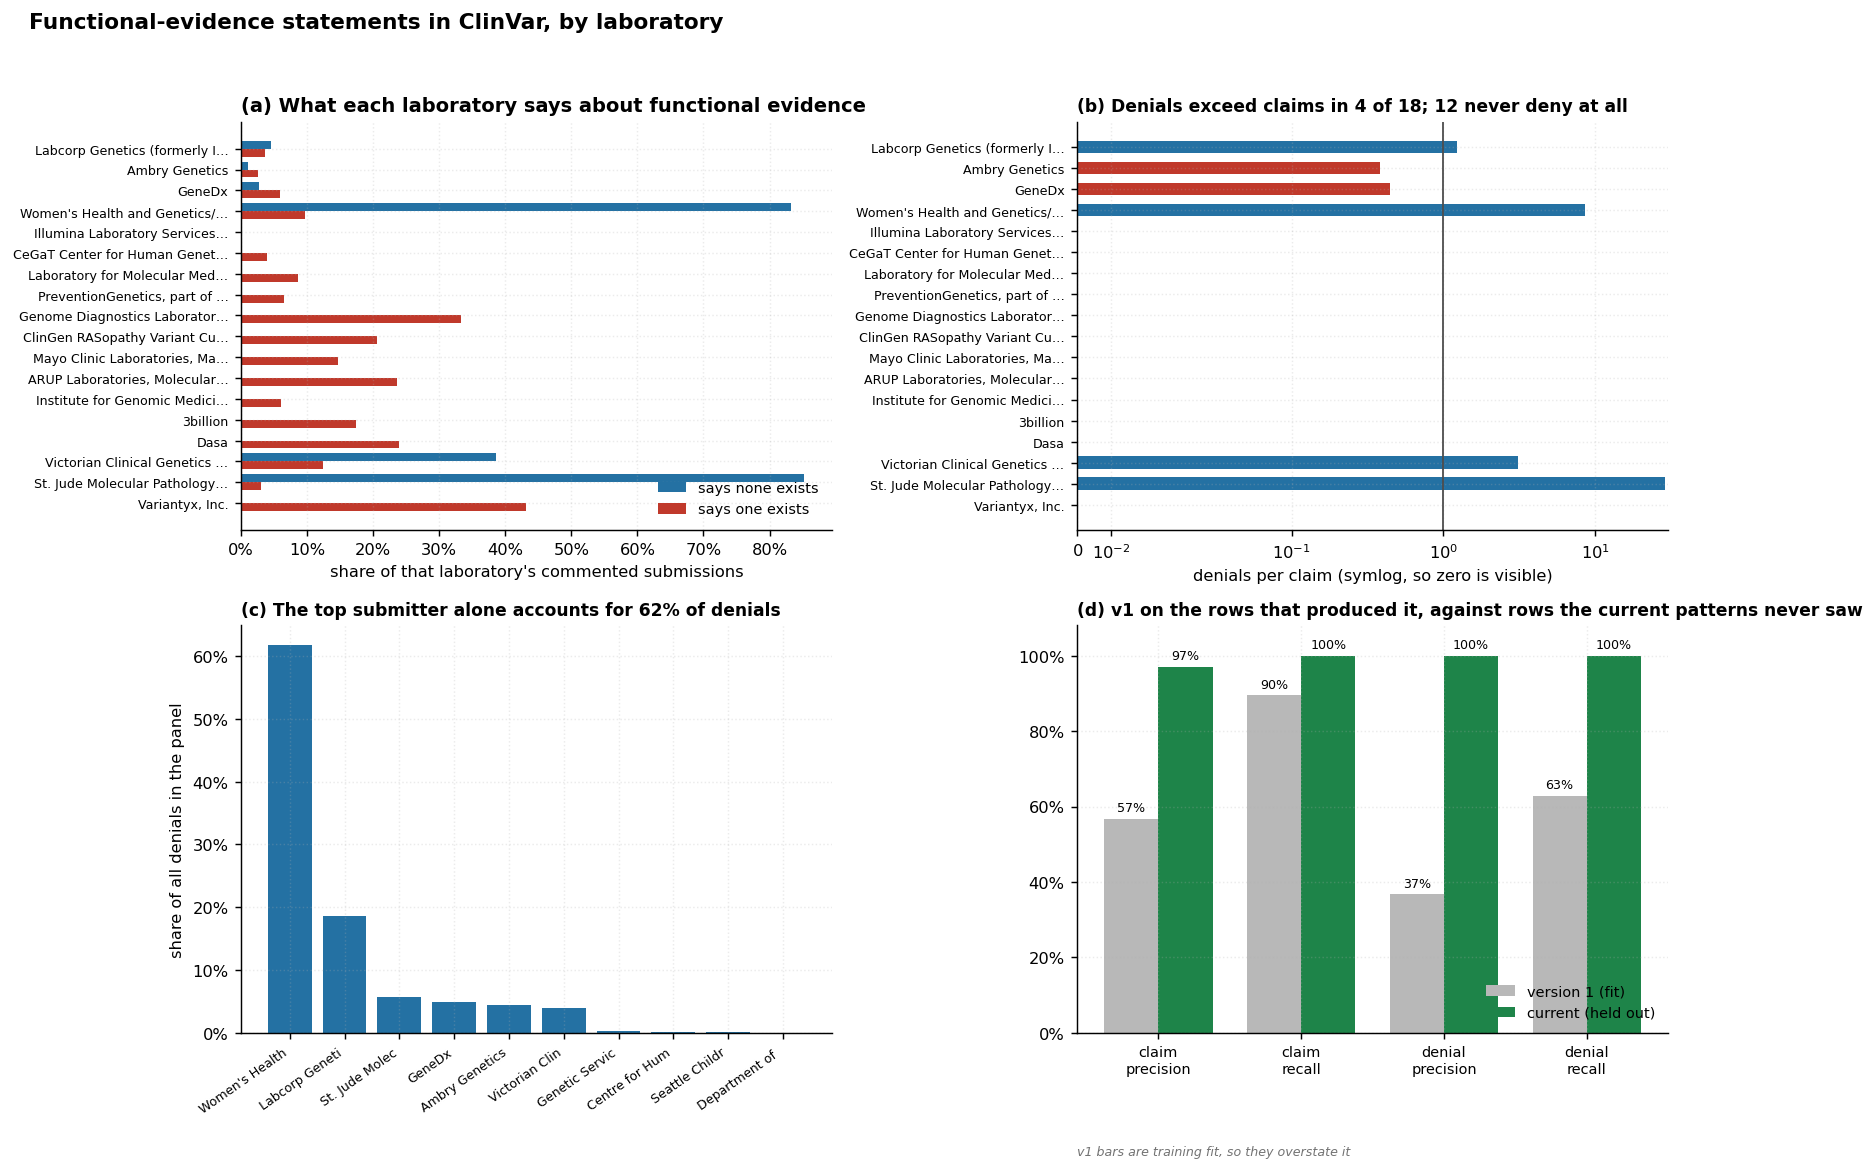

In [7]:
CL, DN, PR = "#c0392b", "#2471a3", "#c9a227"
plt.rcParams.update({"figure.dpi": 130, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "grid.linestyle": ":"})

# Laboratories that say anything at all, ordered by volume.
vocal = big[(big["claims"] + big["denials"]) > 0].head(18)
vocal = vocal.sort_values("submissions", ascending=True)
short = [s if len(s) <= 30 else s[:28] + "…" for s in vocal.index]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- (a) claim and denial rate per laboratory ------------------------------
ax = axes[0, 0]
y = np.arange(len(vocal)); h = 0.38
ax.barh(y + h/2, vocal["denial_rate"], h, color=DN, label="says none exists")
ax.barh(y - h/2, vocal["claim_rate"], h, color=CL, label="says one exists")
ax.set_yticks(y); ax.set_yticklabels(short, fontsize=7)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("share of that laboratory's commented submissions")
ax.set_title("(a) What each laboratory says about functional evidence",
             loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=8, loc="lower right")

# --- (b) the ratio, per laboratory, with the direction counted -------------
ax = axes[0, 1]
r = vocal["denials_per_claim"].replace([np.inf], np.nan).dropna()
if len(r):
    ax.barh(np.arange(len(r)), r.values, 0.6,
            color=[DN if v >= 1 else CL for v in r.values])
    ax.axvline(1, color="0.3", lw=1)
    ax.set_yticks(np.arange(len(r)))
    ax.set_yticklabels([s for s, i in zip(short, vocal.index) if i in r.index],
                       fontsize=7)
    # Log cannot show zero, and zero is the modal value: most laboratories
    # never record an absence. On a log axis they fall off the left edge, which
    # hides the finding.
    _zero = int((r == 0).sum())
    ax.set_xscale("symlog", linthresh=0.05)
    ax.set_xlabel("denials per claim (symlog, so zero is visible)")
    _n_deny = int((r >= 1).sum())
    ax.set_title(f"(b) Denials exceed claims in {_n_deny} of {len(r)}; "
                 f"{_zero} never deny at all",
                 loc="left", fontweight="bold", fontsize=9.5)

# --- (c) why the aggregate lies --------------------------------------------
ax = axes[1, 0]
share = (lab.sort_values("denials", ascending=False)["denials"]
         .head(10) / max(1, lab["denials"].sum()))
ax.bar(range(len(share)), share.values, color=DN)
ax.set_xticks(range(len(share)))
ax.set_xticklabels([s[:14] for s in share.index], rotation=35, ha="right",
                   fontsize=7)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("share of all denials in the panel")
ax.set_title(f"(c) The top submitter alone accounts for "
             f"{100*share.iloc[0]:.0f}% of denials",
             loc="left", fontweight="bold", fontsize=9.5)

# --- (d) how much to trust any of it ---------------------------------------
ax = axes[1, 1]
# Read whichever key names this run produced. A rename in the scoring cell
# should not silently blank this panel.
_v1 = (ACCURACY or {}).get("v1_fit_130") or (ACCURACY or {}).get("v1_training_fit")
_held = (ACCURACY or {}).get("heldout_90") or (ACCURACY or {}).get("v2_heldout")

if _v1 and _held:
    labels, v1v, hv = [], [], []
    for cls in ("claim", "denial"):
        for metric in ("precision", "recall"):
            labels.append(f"{cls}\n{metric}")
            v1v.append(_v1[cls][metric])
            hv.append(_held[cls][metric])
    x = np.arange(len(labels)); w = 0.38
    ax.bar(x - w/2, v1v, w, color="0.72", label="version 1 (fit)")
    ax.bar(x + w/2, hv, w, color="#1e8449", label="current (held out)")
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("(d) v1 on the rows that produced it, against rows the "
                 "current patterns never saw",
                 loc="left", fontweight="bold", fontsize=9.5)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    for xi, v in list(zip(x - w/2, v1v)) + list(zip(x + w/2, hv)):
        if v == v:
            ax.text(xi, v + 0.02, f"{v:.0%}", ha="center", fontsize=7)
    ax.text(0.0, -0.30, "v1 bars are training fit, so they overstate it",
            transform=ax.transAxes, fontsize=7, color="0.45", style="italic")
elif _held:
    labels = [f"{c}\n{m}" for c in ("claim", "denial")
              for m in ("precision", "recall")]
    hv = [_held[c][m] for c in ("claim", "denial")
          for m in ("precision", "recall")]
    ax.bar(np.arange(len(labels)), hv, 0.5, color="#1e8449")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("(d) Measured on held-out rows", loc="left",
                 fontweight="bold", fontsize=9.5)
    for xi, v in enumerate(hv):
        if v == v:
            ax.text(xi, v + 0.02, f"{v:.0%}", ha="center", fontsize=7)
else:
    ax.text(0.5, 0.5, "no held-out set\nnumbers unverified",
            ha="center", va="center", transform=ax.transAxes,
            fontsize=11, color="#c0392b")
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Functional-evidence statements in ClinVar, by laboratory",
             fontsize=12, fontweight="bold", x=0.02, ha="left", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(FIG / "by_laboratory.png", bbox_inches="tight")
plt.show()

## 8. Per-gene view


Kept because the gene spread was real in version 1 even though its
interpretation was not. Here it carries a warning: the number of laboratories
contributing to each gene varies, so a gene-level rate is partly a statement
about who happened to submit.

        submissions  variants  claims  denials  labs  claim_rate  denial_rate  denials_per_claim   mave  claim_rate_lab_mean  denial_rate_lab_mean
gene                                                                                                                                              
BRAF           2640      1412     101      125   110       0.038        0.047              1.238   True                0.074                 0.015
HRAS           1313       721      61       58    88       0.046        0.044              0.951   True                0.074                 0.022
KRAS            949       455      75       40    98       0.079        0.042              0.533   True                0.063                 0.015
LZTR1          8092      4693     232      440   105       0.029        0.054              1.897  False                0.068                 0.029
MAP2K1         1190       709      54       47    69       0.045        0.039              0.870  False               

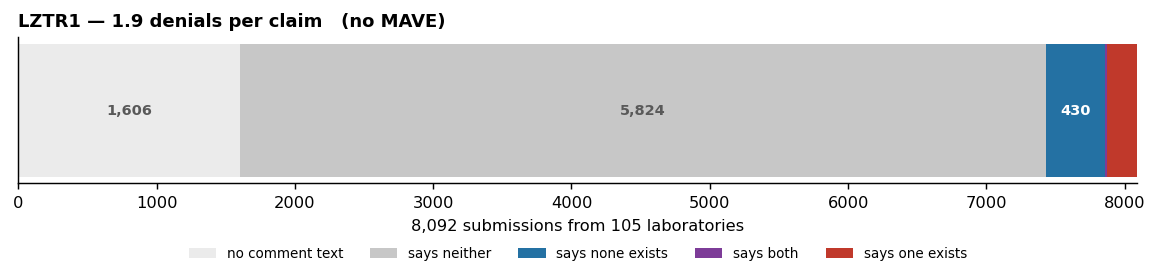

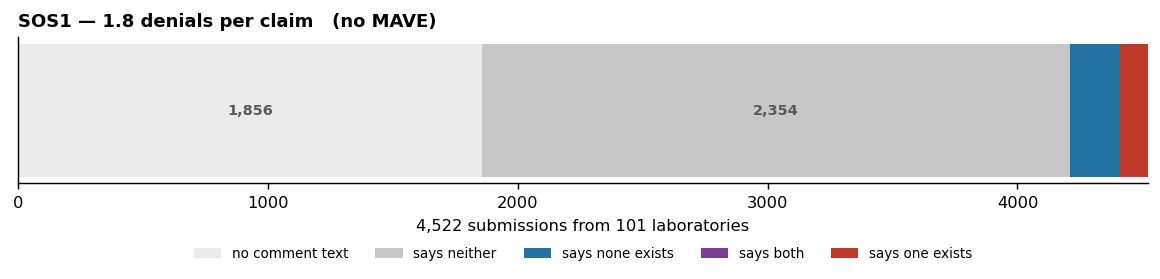

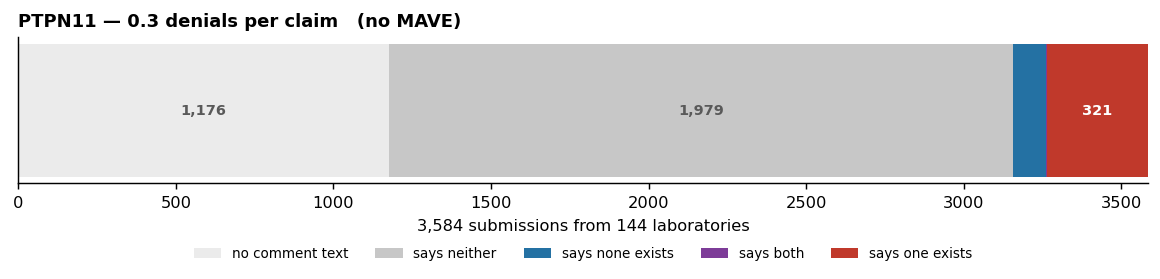

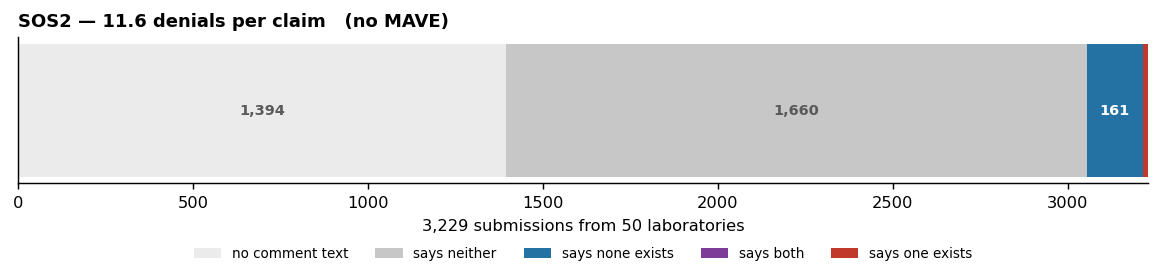

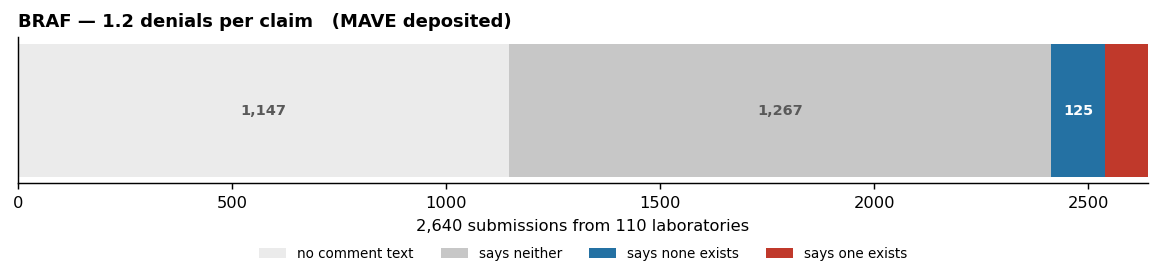

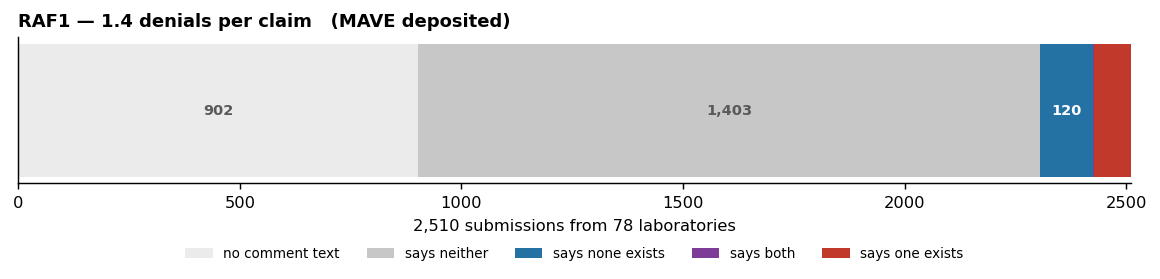

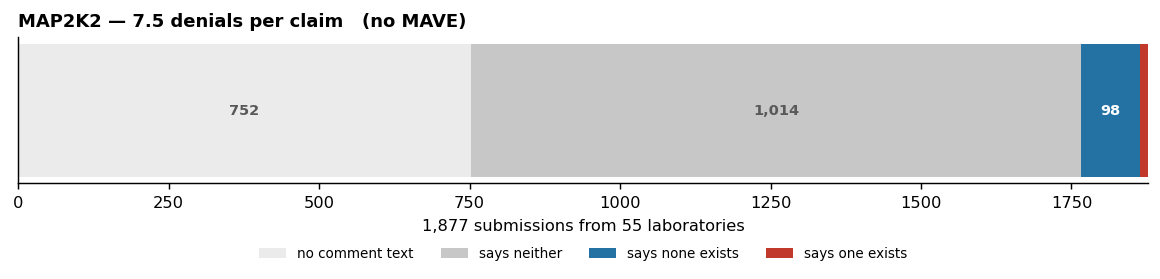

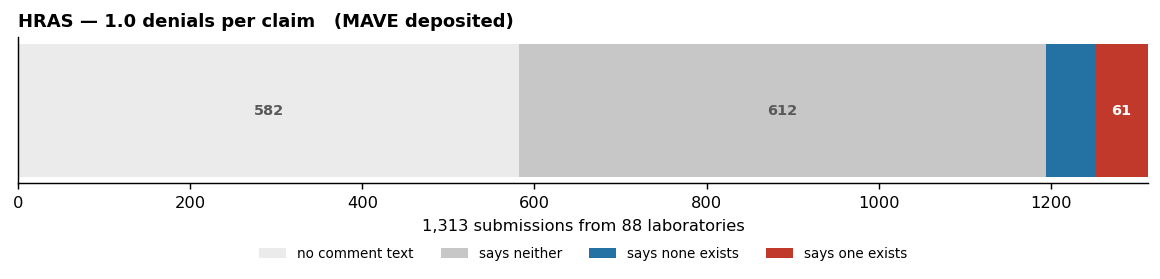

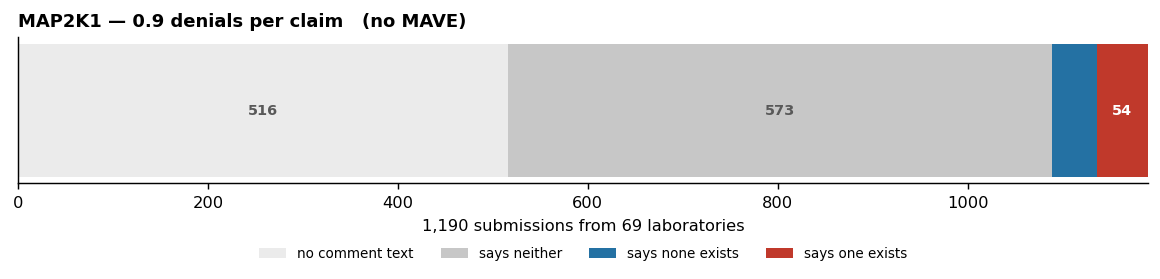

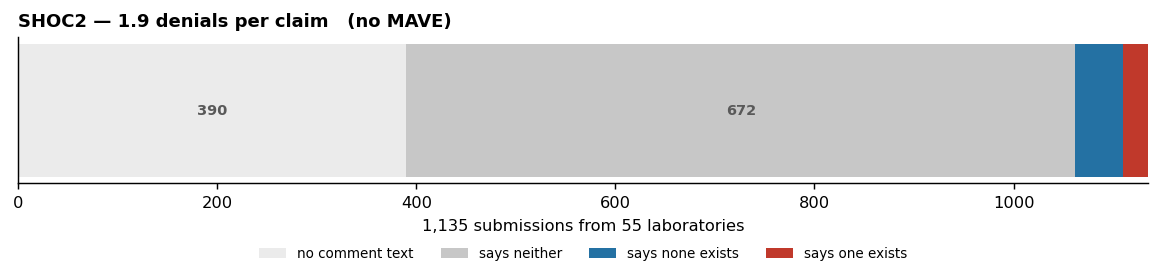

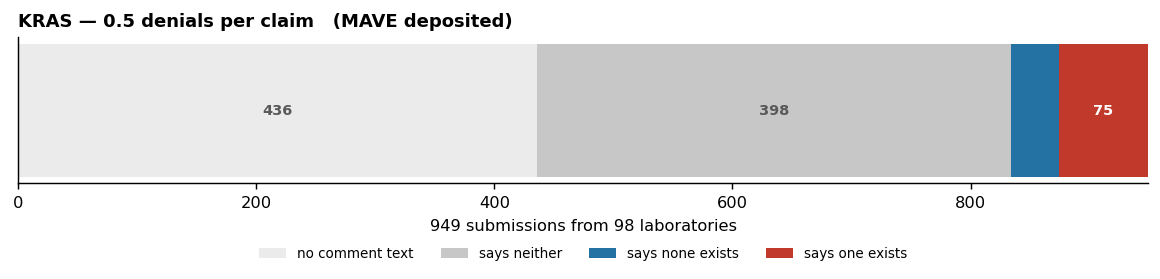

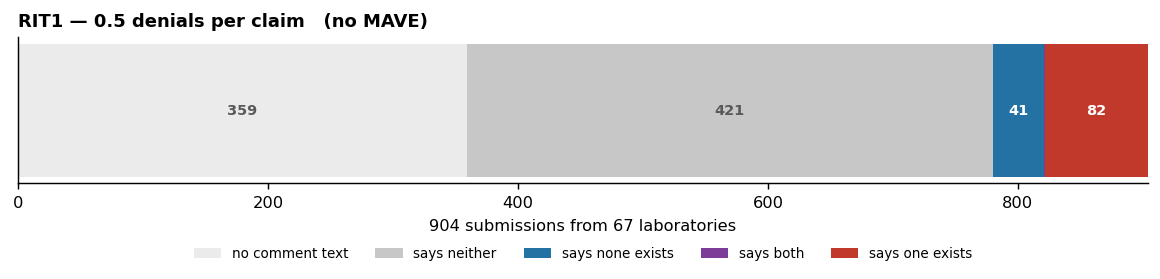

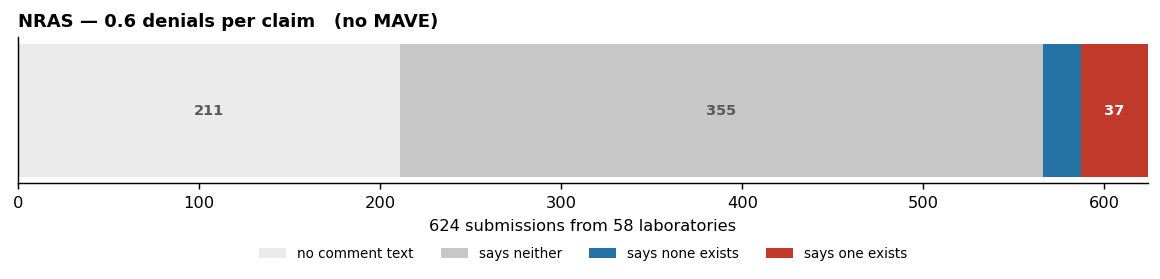

In [8]:
gene_tab = subs.groupby("gene").agg(
    submissions=("SCV", "size"),
    variants=("VariationID", "nunique"),
    claims=("claim", "sum"),
    denials=("denial", "sum"),
    labs=("Submitter", "nunique"),
).reindex(PANEL)
gene_tab["claim_rate"] = gene_tab["claims"] / gene_tab["submissions"]
gene_tab["denial_rate"] = gene_tab["denials"] / gene_tab["submissions"]
gene_tab["denials_per_claim"] = np.where(
    gene_tab["claims"] > 0, gene_tab["denials"] / gene_tab["claims"], np.nan)
gene_tab["mave"] = [g in HAS_MAVE for g in gene_tab.index]

# The same rate computed after collapsing each laboratory to one vote, so a
# single high-volume submitter cannot carry a gene.
per_lab_gene = (subs.groupby(["gene", "Submitter"])
                .agg(c=("claim", "mean"), d=("denial", "mean")))
gene_tab["claim_rate_lab_mean"] = per_lab_gene.groupby("gene")["c"].mean()
gene_tab["denial_rate_lab_mean"] = per_lab_gene.groupby("gene")["d"].mean()

gene_tab.to_csv(OUT / "by_gene.csv")
print(gene_tab.round(3).to_string())

print("""
The two claim-rate columns answer different questions. `claim_rate` weights each
submission equally, so a laboratory filing thousands of comments dominates.
`claim_rate_lab_mean` weights each laboratory equally. Where they disagree
sharply, the gene's figure is a fact about its submitters.""")


def gene_figure(gene, frame, save=True):
    d = frame[frame["gene"] == gene]
    if not len(d):
        return None
    n = len(d)
    c = int(d["claim"].sum()); dn = int(d["denial"].sum())
    b = int(d["both"].sum()); silent = int((~d["has_text"]).sum())
    quiet = n - c - dn + b - silent

    fig, ax = plt.subplots(figsize=(9, 2.5))
    segs = [("no comment text", silent, "0.92"),
            ("says neither", quiet, "0.78"),
            ("says none exists", dn - b, DN),
            ("says both", b, "#7d3c98"),
            ("says one exists", c - b, CL)]
    left = 0
    for label, val, color in segs:
        if val <= 0:
            continue
        ax.barh([0], [val], left=left, color=color, height=0.5, label=label)
        if val / n > 0.045:
            ax.text(left + val/2, 0, f"{val:,}", ha="center", va="center",
                    fontsize=8, fontweight="bold",
                    color="white" if color not in ("0.92", "0.78") else "0.35")
        left += val
    ax.set_xlim(0, n); ax.set_yticks([]); ax.grid(False)
    nlabs = d["Submitter"].nunique()
    ax.set_xlabel(f"{n:,} submissions from {nlabs} laboratories")
    ax.legend(frameon=False, fontsize=7.5, loc="upper center",
              bbox_to_anchor=(0.5, -0.35), ncol=5)
    ratio = f"{dn/c:.1f} denials per claim" if c else "no claims"
    mave = "MAVE deposited" if gene in HAS_MAVE else "no MAVE"
    ax.set_title(f"{gene} — {ratio}   ({mave})",
                 loc="left", fontweight="bold", fontsize=10)
    fig.tight_layout()
    if save:
        fig.savefig(FIG / f"gene_{gene}.png", bbox_inches="tight")
    return fig


for g in gene_tab.sort_values("submissions", ascending=False).index:
    f = gene_figure(g, subs)
    if f:
        plt.show()

## 9. What this run found


Generated from the tables. Every rate is printed with the accuracy that applies
to it, because a rate without one is what version 1 reported.

In [9]:
claims = int(subs["claim"].sum())
denials = int(subs["denial"].sum())
lit = int(subs["lit_absence"].sum())
n = len(subs)

lab_ratio = big["denials_per_claim"].replace([np.inf], np.nan).dropna()
deny_more = int((lab_ratio >= 1).sum())
median_ratio = float(lab_ratio.median()) if len(lab_ratio) else float("nan")

print("=" * 74)
print(f"{n:,} submissions | {claims:,} claims | {denials:,} denials")
if ACCURACY:
    _h = ACCURACY.get("heldout_90") or ACCURACY.get("v2_heldout")
    _f = ACCURACY.get("fit_130") or ACCURACY.get("v2_training_fit")
    _use = _h or _f
    if _use:
        cp, dp = _use["claim"]["precision"], _use["denial"]["precision"]
        _src = "held out" if _h else "TRAINING FIT ONLY - not accuracy"
        print(f"precision ({_src}): claims {cp:.0%}, denials {dp:.0%}")
else:
    print("NO MEASURED ACCURACY - treat every figure as provisional")
print("=" * 74)

print(f"""
Across {len(lab_ratio)} laboratories with at least {MIN_SUBS} submissions,
{deny_more} state more often that functional evidence is absent than that it
exists. The median laboratory files {median_ratio:.2f} denials per claim.

The panel-wide totals are not the answer to the question. One submitter accounts
for {100*top_denials:.0f}% of all denials, and its template decides any aggregate
computed over submissions. Version 1 reported such an aggregate as 5.9 denials
per claim; the same data, read per laboratory, does not support that reading.

{lit:,} submissions state that a variant is absent from the case-report
literature. Version 1 counted those as denials of functional evidence, which is
what produced its number. They are counted separately here and excluded from
both classes.
""")

summary = {
    "version": 5,
    "supersedes": "v1 panel ratio of 5.9 denials per claim - wrong, see header",
    "submissions": n,
    "variants": int(subs["VariationID"].nunique()),
    "claims": claims,
    "denials": denials,
    "both": int(subs["both"].sum()),
    "literature_absence_excluded": lit,
    "submissions_without_text": int((~subs["has_text"]).sum()),
    "laboratories": int(subs["Submitter"].nunique()),
    "laboratories_over_threshold": int(len(big)),
    "laboratories_denying_more_than_claiming": deny_more,
    # Denominator stated alongside, because the two counts above are over
    # different sets: 46 laboratories clear the submission threshold, but only
    # the 26 with at least one claim have a ratio at all. 19 of 26 is 73%;
    # 19 of 46 is 41%, and that is the number a reader will otherwise quote.
    "laboratories_vocal": int(len(lab_ratio)),
    "laboratories_never_denying": int((lab_ratio == 0).sum()),
    "laboratories_never_denying_denominator": "laboratories_vocal",
    "median_lab_denials_per_claim": round(median_ratio, 3),
    "top_submitter_share_of_denials": round(float(top_denials), 4),
    "accuracy": ACCURACY,
    "accuracy_note": ("quote the held-out figures; anything labelled fit was "
                      "measured on the rows that produced the patterns"),
    "not_measured": [
        "whether any claim is true - that needs the cited papers read",
        "whether an assay was performed on this variant or a neighbour",
    ],
}
(OUT / "summary.json").write_text(json.dumps(summary, indent=2, default=str))
print(json.dumps({k: v for k, v in summary.items() if k != "accuracy"}, indent=2))

32,569 submissions | 1,216 claims | 1,512 denials
precision (held out): claims 97%, denials 100%

Across 26 laboratories with at least 30 submissions,
5 state more often that functional evidence is absent than that it
exists. The median laboratory files 0.00 denials per claim.

The panel-wide totals are not the answer to the question. One submitter accounts
for 62% of all denials, and its template decides any aggregate
computed over submissions. Version 1 reported such an aggregate as 5.9 denials
per claim; the same data, read per laboratory, does not support that reading.

5,922 submissions state that a variant is absent from the case-report
literature. Version 1 counted those as denials of functional evidence, which is
what produced its number. They are counted separately here and excluded from
both classes.

{
  "version": 5,
  "supersedes": "v1 panel ratio of 5.9 denials per claim - wrong, see header",
  "submissions": 32569,
  "variants": 17368,
  "claims": 1216,
  "denials": 1512

## 10. Limitations


**Two labelled sets, and only one of them is evidence.** The 130-row set
generated the patterns; scoring on it measures fit and returns near-perfect
numbers that mean nothing. The 110-row held-out set was drawn after the patterns
were frozen and read blind. Quote the held-out figures. The gap between the two
is the size of the overfitting, and it is printed rather than hidden.

**The assay exists, but not on this variant.** Six of the nine remaining claim
false positives are this: an experiment on another substitution at the same
codon, on the wild-type residue, or on missense variants in the gene generally.
Each is a real assay and none is PS3 evidence for the variant in hand - they are
PM5, or mechanism support. The classifier catches the explicitly worded cases and
misses the rest, because deciding what an experiment was performed *on* requires
reading the sentence, not matching it. This is the largest remaining error and
the one no pattern will fix.

**The largest open question is a reading decision, not a bug.** One laboratory
files 2,523 submissions with an and/or boilerplate: *"intact protein function
and/or RNA analysis and/or in silico models"*. Every one is currently classified
as neither, because the sentence asserts nothing about which of the three was
actually done.

If a reviewer decides those are claims, claims go from 1,167 to 3,690 and the
panel ratio falls from 1.18 to 0.37. That single judgement moves the result three
times more than every classifier error found across four audits combined - and no
pattern settles it, because the ambiguity is in the source sentence.

The figure is reported without them. A reader who disagrees can recompute:
`subs[subs.text.str.contains("and/or", case=False)]` isolates the block.

**One fix makes another problem visible.** A sentence like *"functional studies
showed that another variant at the same position caused increased RAS
activation"* was classified as neither while the verb pattern was missing
"showed". With the verb repaired it becomes a claim, and a wrong one - the assay
is on a neighbouring variant. The attribution problem above was partly masked by
a recall hole; closing the hole exposes it. Expect the next audit to find these,
and count them against attribution rather than against the verb fix.

**Recall was measured on the fifth attempt.** The first four versions listed
recall against unlabelled submissions as not measured; a sample of 60 rows from
the "neither" class put it at 88.7%, and the two gaps it exposed - *"studies have
not been performed"* and a line-break artefact splitting words - are fixed above.
Neither moved the headline: 1.18 before and after.

**The same defect appeared twice.** Version 1 wrote an optional group that let a
branch match without the word carrying its meaning; version 2 reproduced it in a
different branch. Section 3 now tests the shape rather than the instance - any
optional group holding a meaning-bearing word is reported. That test would have
caught both.

**Simpson's paradox is documented, not solved.** Reporting per laboratory is the
right unit for this question, but laboratories differ in what they submit, which
genes they cover, and how much they write. A laboratory that denies often may
simply file more borderline variants.

**32.4% of submissions carry no comment.** They can neither claim nor deny. The
share varies from 0% to 100% by submitter, so laboratory-level rates are partly a
measure of documentation habit.

**Claims and denials are not exclusive.** A submission can cite one assay and
note the absence of another. Those are counted in both classes and reported as
`both` rather than forced into one.

**None of this establishes truth.** A claim may be right or wrong; the paper it
cites may or may not contain an assay. The feasibility check found 26% of cited
papers have open full text, which is what a follow-up would be limited to.